In [1]:
# 1. List of all themes (in order)
themes = [
    "Emotional response",
    "Post-layoff precarities",
    "Career trajectory",
    "Collective resistance",
    "Individual survival strategy",
    "Weaponized system",
    "Algorithmic dehumanization",
    "Mass layoff decisions",
    "Tiered precarity"
]

# 2. List of all codes (in order of themes)
all_codes = [
    # Emotional response
    "Fear/Anxiety",
    "Anger/Blame",
    "Shock/Disbelief",
    "Resilience/Hope",
    "Frustration/Disappointment",
    # Post-layoff precarities
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse",
    # Career trajectory
    "Job-search friction",
    "Anticipation & job insecurity",
    "Career change",
    # Collective resistance
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott",
    # Individual survival strategy
    "Upskilling",
    "Job search",
    "Discussing severance",
    "Next offer in hand",
    "Seeking legal advice",
    # Weaponized system
    "Coercive PIPs/Focus",
    "Blame-shifting",
    "Disability discrimination",
    "Legal gaslighting",
    "Corporate euphemisms",
    # Algorithmic dehumanization
    "Recruiter ghosting",
    "Résumé-filter bias",
    "Visa-filter bias",
    # Mass layoff decisions
    "Profit maximization",
    "News of mass layoff",
    # Tiered precarity
    "Startup/Small Tech vulnerability",
    "Big Tech privilege",
    "Industry contagion"
]

# 3. Lists for each theme and associated codes
emotional_response = [
    "Fear/Anxiety",
    "Anger/Blame",
    "Shock/Disbelief",
    "Resilience/Hope",
    "Frustration/Disappointment"
]
post_layoff_precarities = [
    "Immigration limbo",
    "Family struggle",
    "Financial insecurity",
    "Professional identity collapse"
]
career_trajectory = [
    "Job-search friction",
    "Anticipation & job insecurity",
    "Career change"
]
collective_resistance = [
    "Resource-sharing",
    "Legal mobilization",
    "Organizing boycott"
]
individual_survival_strategy = [
    "Upskilling",
    "Job search",
    "Discussing severance",
    "Next offer in hand",
    "Seeking legal advice"
]
weaponized_system = [
    "Coercive PIPs/Focus",
    "Blame-shifting",
    "Disability discrimination",
    "Legal gaslighting",
    "Corporate euphemisms"
]
algorithmic_dehumanization = [
    "Recruiter ghosting",
    "Resume-filter bias",
    "Visa-filter bias"
]
mass_layoff_decisions = [
    "Profit maximization",
    "News of mass layoff"
]
tiered_precarity = [
    "Startup/Small Tech vulnerability",
    "Big Tech privilege",
    "Industry contagion"
]

In [20]:
import json
jsonl_file = "teamblind_posts_with_post_id_and_labels.jsonl"  # Replace with your actual file path

code_set = set()

with open(jsonl_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            try:
                entry = json.loads(line)
                for code in entry.get("codes", []):
                    code_set.add(code)
            except json.JSONDecodeError:
                print("Error decoding JSON line:", line.strip())
                continue
# Final output
print("Unique Codes Found:")
for code in sorted(code_set):
    print("-", code)
print(f"\nTotal unique codes: {len(code_set)}")


Unique Codes Found:
- Anger/Blame
- Anticipation & job insecurity
- Big Tech privilege
- Blame-shifting
- Career change
- Coercive PIPs/Focus
- Corporate euphemisms
- Disability discrimination
- Discussing severance
- Family struggle
- Fear/Anxiety
- Financial insecurity
- Frustration/Disappointment
- Immigration limbo
- Industry contagion
- Job search
- Job-search friction
- Legal gaslighting
- Legal mobilization
- News of mass layoff
- Next offer in hand
- Organizing boycott
- Professional identity collapse
- Profit maximization
- Recruiter ghosting
- Resilience/Hope
- Resource-sharing
- Résumé-filter bias
- Seeking legal advice
- Shock/Disbelief
- Startup/Small Tech vulnerability
- Upskilling
- Visa-filter bias

Total unique codes: 33


## checking for missing code

In [21]:
missing_codes = code_set - set(all_codes)  # Codes in code_set but not in all_codes
print(f"Missing Codes: {missing_codes}")

Missing Codes: set()


In [22]:
import json

# file path to your jsonl file
#file_path = "your_file.jsonl"

# missing codes you mentioned
missing_codes = {
    "Collective resistance",
    "Algorithmic dehumanization",
    "Tiered precarity"
}

# store results as {code: [post_ids]}
code_to_posts = {code: [] for code in missing_codes}

with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        data = json.loads(line)
        post_id = data.get("post_id")
        codes = data.get("codes", [])
        
        for code in codes:
            if code in missing_codes:
                code_to_posts[code].append(post_id)

# print results
for code, posts in code_to_posts.items():
    print(f"{code}: {posts}")


Tiered precarity: []
Algorithmic dehumanization: []
Collective resistance: []


In [13]:
import json

# Input/Output
jsonl_file = "teamblind_posts_with_post_id_and_labels.jsonl"
out_file = "posts_with_missing_codes.jsonl"

# Target codes in required order
ordered_codes = [
    "Tiered precarity",
    "Algorithmic dehumanization",
    "Collective resistance",
]

# Post IDs you provided for each code
ids_by_code = {
    "Tiered precarity": [638, 640, 682, 700, 890, 902, 913, 940, 1514, 4118, 5020, 5525, 5571, 7944, 8006, 8073, 8076],
    "Algorithmic dehumanization": [594, 893, 1554, 5299, 6399, 6538, 7709],
    "Collective resistance": [1829, 1996, 4805, 4958, 5028, 5110, 5174, 5195, 5223, 5228, 5278, 6972, 7433, 7704, 8390, 8412],
}

# Load all posts into a dict by post_id for quick lookup
posts_by_id = {}
with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        obj = json.loads(line)
        pid = obj.get("post_id")
        if pid is not None:
            posts_by_id[pid] = obj

# Write selected posts to one JSONL, grouped by code order
with open(out_file, "w", encoding="utf-8") as out:
    for code in ordered_codes:
        for pid in ids_by_code.get(code, []):
            post = posts_by_id.get(pid)
            if not post:
                continue  # skip if the ID isn't in the source file
            # ensure the post actually has the code (defensive)
            if code in set(post.get("codes", [])):
                out.write(json.dumps(post, ensure_ascii=False) + "\n")


In [14]:
for key, value in ids_by_code.items():
    print(f"{key}: count={len(value)}, posts={value}")

Tiered precarity: count=17, posts=[638, 640, 682, 700, 890, 902, 913, 940, 1514, 4118, 5020, 5525, 5571, 7944, 8006, 8073, 8076]
Algorithmic dehumanization: count=7, posts=[594, 893, 1554, 5299, 6399, 6538, 7709]
Collective resistance: count=16, posts=[1829, 1996, 4805, 4958, 5028, 5110, 5174, 5195, 5223, 5228, 5278, 6972, 7433, 7704, 8390, 8412]


## visuals

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# === Step 1: Load JSONL file ===
# Replace with your actual file path
jsonl_file = "teamblind_posts_with_post_id_and_labels.jsonl"

df = pd.read_json(jsonl_file, lines=True)

# Ensure 'date' is datetime and derive 'month'
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

/tmp/ipykernel_500355/3508709279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")


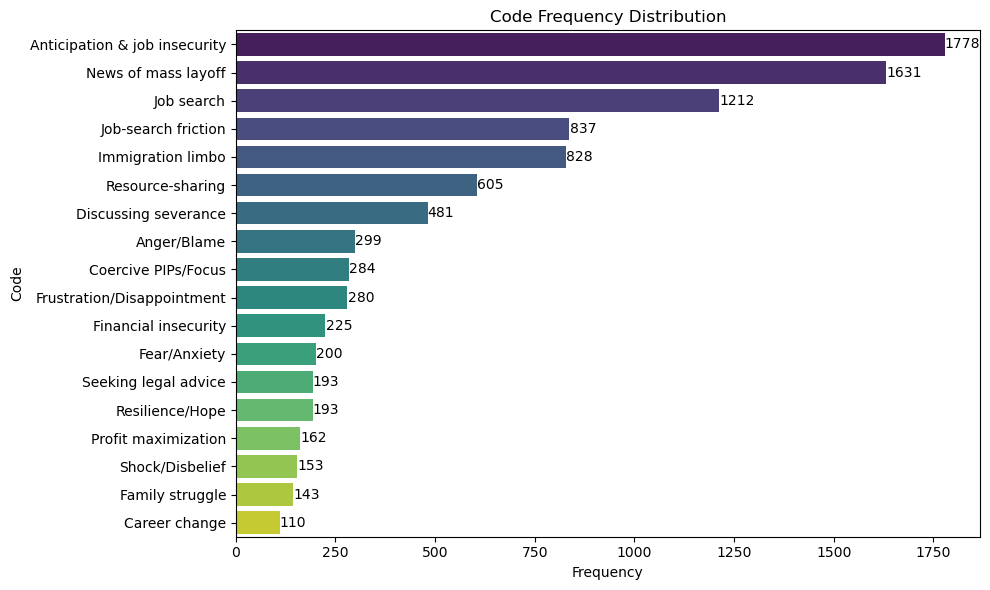

codes
Anticipation & job insecurity    1778
News of mass layoff              1631
Job search                       1212
Job-search friction               837
Immigration limbo                 828
Resource-sharing                  605
Discussing severance              481
Anger/Blame                       299
Coercive PIPs/Focus               284
Frustration/Disappointment        280
Financial insecurity              225
Fear/Anxiety                      200
Seeking legal advice              193
Resilience/Hope                   193
Profit maximization               162
Shock/Disbelief                   153
Family struggle                   143
Career change                     110
Name: count, dtype: int64


/tmp/ipykernel_500355/3508709279.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")


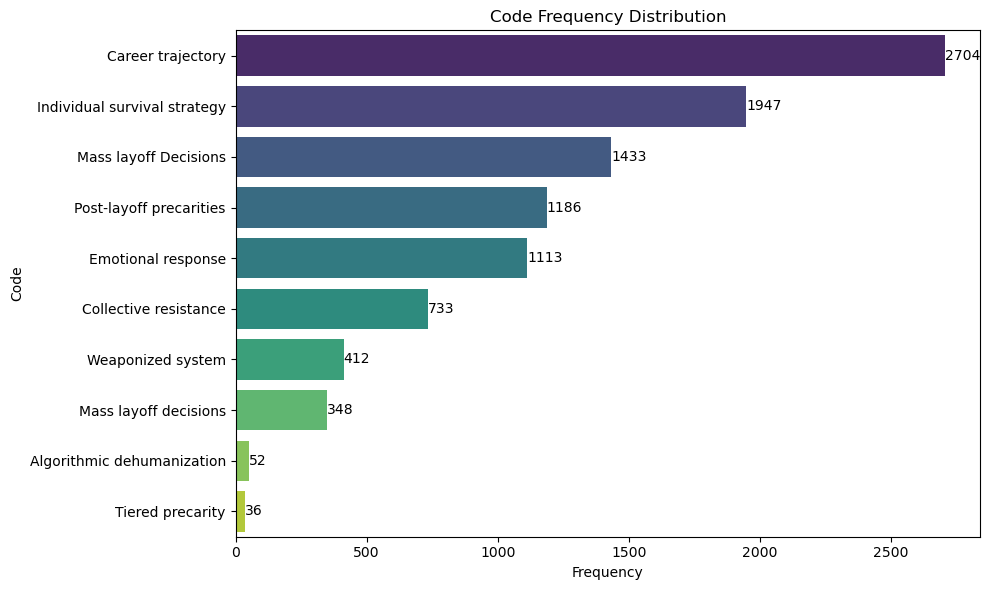

themes
Career trajectory               2704
Individual survival strategy    1947
Mass layoff Decisions           1433
Post-layoff precarities         1186
Emotional response              1113
Collective resistance            733
Weaponized system                412
Mass layoff decisions            348
Algorithmic dehumanization        52
Tiered precarity                  36
Name: count, dtype: int64


In [12]:



# Code frequency bar chart
all_codes = df['codes'].explode()
code_freq = all_codes.value_counts().sort_values(ascending=False)
# only keep codes with more than 100 occurrences
code_freq = code_freq[code_freq > 100]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=code_freq.values, y=code_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(code_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(code_freq)



# theme frequency bar chart
all_themes = df['themes'].explode()
theme_freq = all_themes.value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=theme_freq.values, y=theme_freq.index, palette="viridis")
plt.title("Code Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Code")
plt.tight_layout()

# Add text labels to each bar
for i, v in enumerate(theme_freq.values):
    ax.text(v + 0.5, i, str(v), color='black', va='center')

plt.show()

print(theme_freq)

# save code frequency to CSV
code_freq.to_csv("code_frequency.csv", header=True)
# save theme frequency to CSV
theme_freq.to_csv("theme_frequency.csv", header=True)


In [ ]:
import numpy as np
# Initialize empty co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=all_codes, columns=all_codes)

# Fill matrix from code list per post
for code_list in df['codes']:
    for c1, c2 in combinations(code_list, 2):
        co_occurrence.at[c1, c2] += 1
        co_occurrence.at[c2, c1] += 1
    for c in code_list:
        co_occurrence.at[c, c] += 1  # include diagonal

# Apply log scale for better contrast
log_scaled = np.log1p(co_occurrence)

# Create mask for upper triangle
mask = np.tril(np.ones_like(log_scaled, dtype=bool))

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(log_scaled, mask=mask, cmap="YlGnBu", square=True,
            linewidths=0.5, cbar_kws={"label": "log(1 + count)"})
plt.title("Code Co-occurrence Heatmap (log scale, lower triangle)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# === Step 5: Monthly Trends for Selected Codes ===

def plot_monthly_trends(df, sample_codes):
    df_exploded = df.explode('codes')
    monthly_trends = (
        df_exploded[df_exploded['codes'].isin(sample_codes)]
        .groupby(['month', 'codes'])
        .size()
        .unstack(fill_value=0)
    )

    monthly_trends.plot(kind='line', marker='o', figsize=(10, 6))
    plt.title("Monthly Trends of Selected Codes")
    plt.xlabel("Month")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

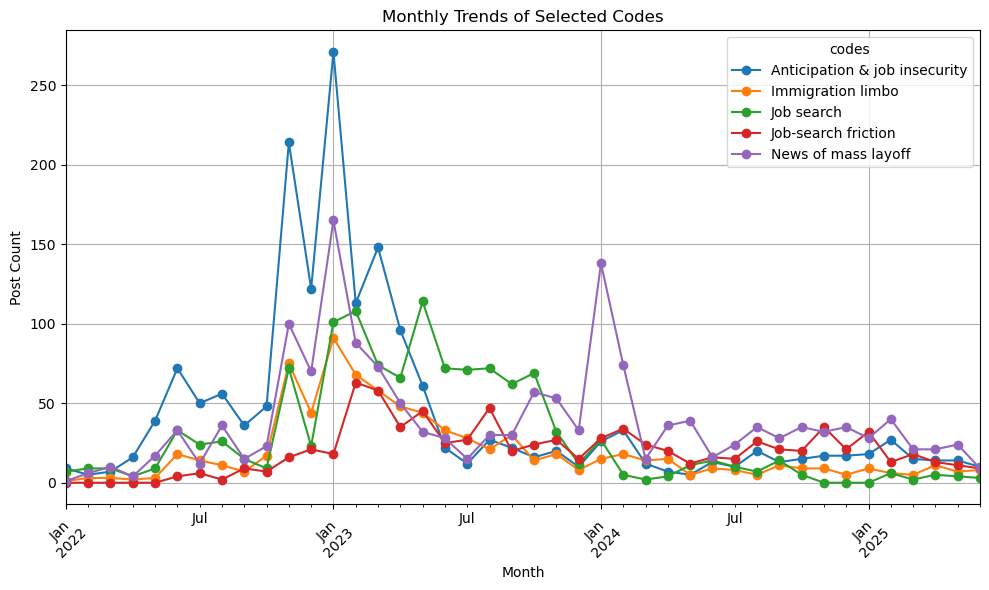

In [8]:
top_5_codes = ["Anticipation & job insecurity", "News of mass layoff", "Job search", "Job-search friction", "Immigration limbo"]
plot_monthly_trends(df, top_5_codes)


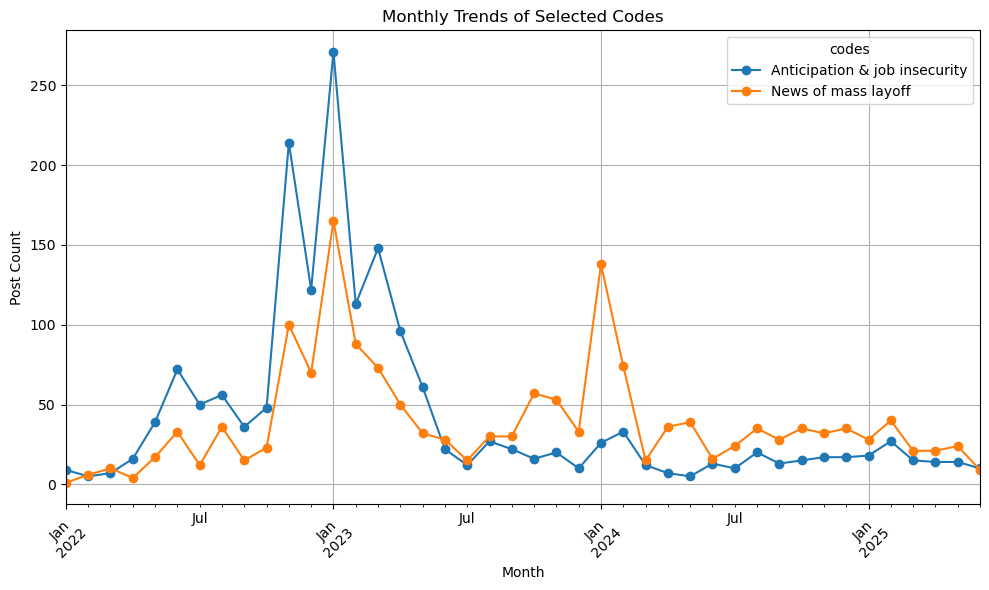

In [9]:
# digging deeper
top_2_codes = ["Anticipation & job insecurity", "News of mass layoff"]
plot_monthly_trends(df, top_2_codes)